In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataKMeans").config("spark.driver.memory", "4g").config("spark.executor.memory", "8g") .config("spark.executor.cores", "4").config("spark.sql.shuffle.partitions", 400) .getOrCreate()

# Read multiline json file
multiline_df = spark.read.option("multiline","true") \
      .json("/content/gdrive/MyDrive/ingredients/train.json")
#multiline_df.toPandas()

In [ ]:
multiline_df.printSchema()

root
 |-- cuisine: string (nullable = true)
 |-- id: long (nullable = true)
 |-- ingredients: array (nullable = true)
 |    |-- element: string (containsNull = true)



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, expr


for ingredients in multiline_df.columns:
    # بررسی اینکه آیا نوع ستون آرایه از رشته است یا نه
    if dict(multiline_df.dtypes)[ingredients] == "array<string>":
        # تبدیل عناصر آرایه به حروف کوچک
        multiline_df = multiline_df.withColumn(ingredients, expr(f"transform({ingredients}, x -> lower(x))"))
    elif dict(multiline_df.dtypes)[ingredients] == "string":
        # تبدیل رشته‌های تکی به حروف کوچک
        multiline_df = multiline_df.withColumn(ingredients, lower(col(ingredients)))

In [ ]:
multiline_df.toPandas()

,cuisine,id,ingredients
0,greek,10259,"[romaine lettuce, black olives, grape tomatoes..."
1,southern_us,25693,"[plain flour, ground pepper, salt, tomatoes, g..."
2,filipino,20130,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,indian,22213,"[water, vegetable oil, wheat, salt]"
4,indian,13162,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,irish,29109,"[light brown sugar, granulated sugar, butter, ..."
39770,italian,11462,"[kraft zesty italian dressing, purple onion, b..."
39771,irish,2238,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,chinese,41882,"[boneless chicken skinless thigh, minced garli..."


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, ArrayType
import inflect

# Initialize inflect engine
p = inflect.engine()

def singularize(word):
    if isinstance(word, list):
        # If word is a list, singularize each element
        return [p.singular_noun(w) if p.singular_noun(w) else w for w in word]
    elif isinstance(word, str):
        # If word is a string, singularize it directly
        return p.singular_noun(word) if p.singular_noun(word) else word
    return word

# Register the UDF with PySpark, specifying ArrayType for list inputs
singularize_udf = udf(singularize, ArrayType(StringType()))

# Apply the UDF to the specific columns (replace 'column_name' with your actual column)
df_singular = multiline_df.withColumn("ingredients", singularize_udf(multiline_df["ingredients"]))

#df_singular.toPandas()

# Write the updated DataFrame back to a JSON file
#df_singular.write.json("/content/gdrive/MyDrive/ingredients/train_new.json")

In [ ]:
from pyspark.ml.feature import StopWordsRemover

# 2. حذف Stop Words
remover = StopWordsRemover(inputCol="ingredients", outputCol="StopWordsRemoved")
filtered_df = remover.transform(df_singular)

In [ ]:
filtered_df.limit(50).toPandas()

,cuisine,id,ingredients,StopWordsRemoved
0,greek,10259,"[romaine lettuce, black olive, grape tomato, g...","[romaine lettuce, black olive, grape tomato, g..."
1,southern_us,25693,"[plain flour, ground pepper, salt, tomato, gro...","[plain flour, ground pepper, salt, tomato, gro..."
2,filipino,20130,"[egg, pepper, salt, mayonaise, cooking oil, gr...","[egg, pepper, salt, mayonaise, cooking oil, gr..."
3,indian,22213,"[water, vegetable oil, wheat, salt]","[water, vegetable oil, wheat, salt]"
4,indian,13162,"[black pepper, shallot, cornflour, cayenne pep...","[black pepper, shallot, cornflour, cayenne pep..."
5,jamaican,6602,"[plain flour, sugar, butter, egg, fresh ginger...","[plain flour, sugar, butter, egg, fresh ginger..."
6,spanish,42779,"[olive oil, salt, medium shrimp, pepper, garli...","[olive oil, salt, medium shrimp, pepper, garli..."
7,italian,3735,"[sugar, pistachio nut, white almond bark, flou...","[sugar, pistachio nut, white almond bark, flou..."
8,mexican,16903,"[olive oil, purple onion, fresh pineapple, por...","[olive oil, purple onion, fresh pineapple, por..."
9,italian,12734,"[chopped tomato, fresh basil, garlic, extra-vi...","[chopped tomato, fresh basil, garlic, extra-vi..."


In [ ]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import explode

df_exploded = filtered_df.withColumn("ingredient", explode("StopWordsRemoved"))

indexer = StringIndexer(inputCol="ingredient" , outputCol="ingredientIndex")
indexed = indexer.fit(df_exploded).transform(df_exploded)
#indexed.show()

In [ ]:
indexed.toPandas()

,cuisine,id,ingredients,ingredient,ingredientIndex
0,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",romaine lettuce,296.0
1,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",black olive,337.0
2,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",grape tomato,342.0
3,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",garlic,4.0
4,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",pepper,10.0
...,...,...,...,...,...
428270,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",garlic,4.0
428271,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",white sugar,74.0
428272,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",roma tomato,345.0
428273,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",celery,101.0


In [ ]:
df_exploded.toPandas()

,cuisine,id,ingredients,ingredient
0,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",romaine lettuce
1,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",black olive
2,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",grape tomato
3,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",garlic
4,greek,10259,"[romaine lettuce, black olive, grape tomato, g...",pepper
...,...,...,...,...
428270,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",garlic
428271,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",white sugar
428272,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",roma tomato
428273,mexican,2362,"[green chile, jalapeno chili, onion, ground bl...",celery


In [ ]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(inputCol="ingredientIndex", outputCol="ingredientVec")
df_one_hot = encoder.fit(indexed).transform(indexed)

df_one_hot.show()

+-----------+-----+--------------------+--------------------+-------------------+---------------+------------------+
|    cuisine|   id|         ingredients|    StopWordsRemoved|         ingredient|ingredientIndex|     ingredientVec|
+-----------+-----+--------------------+--------------------+-------------------+---------------+------------------+
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|    romaine lettuce|          296.0|(6694,[296],[1.0])|
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|        black olive|          337.0|(6694,[337],[1.0])|
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|       grape tomato|          341.0|(6694,[341],[1.0])|
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|             garlic|            4.0|  (6694,[4],[1.0])|
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|             pepper|           10.0| (6694,[10],[1.0])|
|      greek|10259|[romaine lettuce,...|[romaine lettuce,...|   

In [ ]:
df_one_hot.printSchema()

root
 |-- cuisine: string (nullable = true)
 |-- id: long (nullable = true)
 |-- ingredients: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- StopWordsRemoved: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ingredient: string (nullable = true)
 |-- ingredientIndex: double (nullable = false)
 |-- ingredientVec: vector (nullable = true)



In [ ]:
from pyspark.ml.linalg import Vectors, DenseVector
from pyspark.sql.functions import col, udf, collect_list
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import ArrayType, FloatType

#  id مرحله 1: جمع‌آوری بردارها برای هر
grouped_df = df_one_hot.groupBy("id","cuisine").agg(
    collect_list("ingredientVec").alias("vectors")
)

# مرحله 2: ترکیب بردارها به یک بردار واحد
def merge_vectors(vectors):
    merged = sum(vectors, DenseVector([0.0] * len(vectors[0])))  # بردار نهایی
    return merged

merge_udf = udf(merge_vectors, VectorUDT())

# افزودن ستون ترکیب‌ شده
result_df = grouped_df.withColumn("combined_vector", merge_udf(col("vectors")))

# نمایش نتیجه
#result_df.select("id","cuisine", "combined_vector").show(truncate=False)

In [ ]:
from pyspark.ml.linalg import SparseVector, VectorUDT
from pyspark.sql.functions import col, udf, collect_list
from pyspark.sql.types import IntegerType

# id مرحله 1: جمع‌آوری بردارها برای هر
grouped_df = df_one_hot.groupBy("id", "cuisine").agg(
    collect_list("ingredientVec").alias("vectors")
)

# واحد SparseVector  مرحله 2: ترکیب بردارها با یک
def merge_sparse_vectors(vectors):
    size = len(vectors[0])  # اندازه بردار
    indices = []
    values = []

    for vec in vectors:
        sparse_vec = vec.toArray() if isinstance(vec, SparseVector) else vec
        for i, value in enumerate(sparse_vec):
            if value != 0.0:
                indices.append(i)
                values.append(value)

    # حذف مقادیر تکراری و جمع مقادیر مشابه
    combined_indices = list(set(indices))
    combined_indices.sort()
    combined_values = [sum(values[j] for j, idx in enumerate(indices) if idx == i) for i in combined_indices]

    return SparseVector(size, combined_indices, combined_values)

# VectorUDT با استفاده از  UDF  تعریف
merge_udf = udf(merge_sparse_vectors, VectorUDT())

# افزودن ستون ترکیبی
result_df = grouped_df.withColumn("combined_vector", merge_udf(col("vectors")))

# نمایش نتیجه
# result_df.select("id", "cuisine", "combined_vector").show(truncate=False)


In [ ]:
result_df.select("id", "cuisine", "combined_vector").show(truncate=False)

+---+-----------+------------------------------------------------------------------------------------------------------------------------------------------------------+
|id |cuisine    |combined_vector                                                                                                                                       |
+---+-----------+------------------------------------------------------------------------------------------------------------------------------------------------------+
|1  |mexican    |(6694,[0,4,16,20,21,24,56,65,79,82,100,188,198,438,571,1022,1101,4358],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])     |
|2  |french     |(6694,[0,7,12,28,42,53,69,140,146,178,207,477,525,609,2366,2521,3318,4183],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0]) |
|3  |chinese    |(6694,[4,13,15,17,18,31,46,126,198,199,202],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])                                                

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec

# Word2Vec تنظیمات
word2vec = Word2Vec(vectorSize=100, minCount=0, inputCol="ingredient", outputCol="resultvector")

# Word2Vec آموزش مدل
model = word2vec.fit(df_exploded)

# Word2Vec تبدیل دیتا به فضای
result = model.transform(df_exploded)

# نمایش نتایج
result.select("id", "resultvector").show(truncate=False)




In [ ]:
result.select("id", "result").toPandas()

,id,result
0,10259,"[-0.41981600473324454, -0.06612117009030448, 0..."
1,25693,"[0.012602208351547068, 0.38496563922275195, 0...."
2,20130,"[0.0961624882183969, -0.034711710875853896, 0...."
3,22213,"[0.1475326307117939, 0.011754896491765976, 0.0..."
4,13162,"[0.056269307485490576, -0.13897926397621632, 0..."
...,...,...
39769,29109,"[0.2353938464075327, 0.7532920526961485, -0.20..."
39770,11462,"[-0.10507168833698545, -0.04915941719497953, 0..."
39771,2238,"[0.11947315884754062, 0.41688086154560244, -0...."
39772,41882,"[0.7435616020645414, 0.0017939046291368347, 0...."


In [ ]:
result.select("resultvector").printSchema()

root
 |-- resultvector: vector (nullable = true)



In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, DoubleType

# Vector به Array تبدیل
result = result.withColumn("result_array", F.udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))(F.col("resultvector")))

# محاسبه میانگین برای هر بردار
df_avg = result.select(
    "id",
    F.expr("aggregate(result_array, 0D, (acc, x) -> acc + x, acc -> acc / size(result_array))").alias("result_avg")
)

In [ ]:
df_avg.toPandas()

,id,result_avg
0,10259,-0.063249
1,25693,-0.085572
2,20130,0.108520
3,22213,0.072627
4,13162,0.164470
...,...,...
39769,29109,-0.208572
39770,11462,-0.001319
39771,2238,-0.116736
39772,41882,0.332818


In [ ]:
df_avg.printSchema()

root
 |-- id: long (nullable = true)
 |-- result_avg: double (nullable = true)



In [ ]:
df_avg = df_avg.fillna(0)


In [ ]:
from pyspark.ml.feature import VectorAssembler

# تبدیل داده‌ها به فرمت برداری
assembler = VectorAssembler(inputCols=["result_avg"], outputCol="features")
vector_data = assembler.transform(df_avg)


In [ ]:
vector_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- result_avg: double (nullable = true)
 |-- features: vector (nullable = true)



In [ ]:
vector_data.select("features").toPandas()

,features
0,[-0.06324915256765153]
1,[-0.08557157946581191]
2,[0.1085195435055842]
3,[0.07262658840045333]
4,[0.164470398008901]
...,...
39769,[-0.208571622096416]
39770,[-0.0013185788966005678]
39771,[-0.11673572550838192]
39772,[0.3328175426771243]


In [ ]:
sample_data = vector_data.sample(fraction=0.1, seed=42)  # نمونه‌گیری 10٪ از داده‌ها


In [ ]:
sample_data = sample_data.fillna(0)

In [ ]:
sample_data.toPandas()

,id,result_avg,features
0,3735,0.437333,[0.4373334994345593]
1,34466,0.359671,[0.3596705828482906]
2,2941,-0.190059,[-0.19005941584085426]
3,5767,-0.170359,[-0.1703585666190419]
4,2646,0.299747,[0.2997468268343558]
...,...,...,...
3926,8279,0.471476,[0.4714761657847298]
3927,39166,0.122455,[0.12245511116149525]
3928,45025,0.249410,[0.24940989833946028]
3929,5680,0.122907,[0.12290694582043216]


In [ ]:
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

#  WCSS محاسبه خطای
cost = []
k_values = range(2, 15)

for k in k_values:
    print(f"Running KMeans with k={k}")
    kmeans = KMeans().setK(k).setSeed(1).setFeaturesCol("features")
    model = kmeans.fit(sample_data)
    wssse = model.summary.trainingCost  # خطای WSSSE
    cost.append(wssse)

# Elbow رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(k_values, cost, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS Value")
plt.show()


In [ ]:
sample_data = result_df.sample(fraction=0.1, seed=42)  # نمونه‌گیری 10٪ از داده‌ها


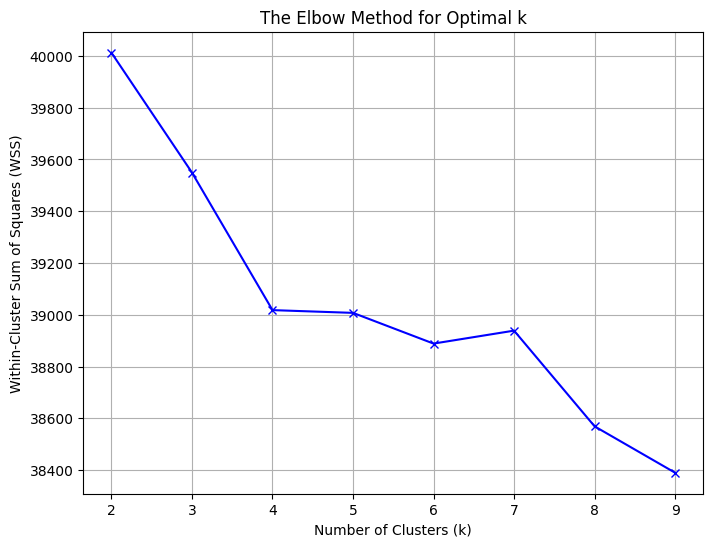

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

cost = []
K = range(2, 10)  #از 1 تا 9  k  بررسی

for k in K:
    kmeans = KMeans().setK(k).setSeed(1).setFeaturesCol("combined_vector")
    model = kmeans.fit(sample_data)
    wss = model.summary.trainingCost  # مجموع مربعات خطا
    cost.append(wss)

    # پیش‌بینی خوشه‌ها
    predictions = model.transform(sample_data)

# Elbow رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(K, cost, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.title('The Elbow Method for Optimal k')
plt.grid()
plt.show()

In [ ]:
model.write().overwrite().save("/content/gdrive/MyDrive/ingredients/modelsave")


In [ ]:
from pyspark.ml.clustering import KMeansModel

# بارگذاری مدل
loaded_model = KMeansModel.load("/content/gdrive/MyDrive/ingredients/modelsave")


In [ ]:
# پیش‌بینی با مدل بارگذاری شده
predictions = loaded_model.transform(sample_data)
predictions.show()

+---+-----------+--------------------+--------------------+----------+
| id|    cuisine|             vectors|     combined_vector|prediction|
+---+-----------+--------------------+--------------------+----------+
| 15|    mexican|[(6694,[3],[1.0])...|(6694,[3,43,57,80...|         2|
| 46|     indian|[(6694,[11],[1.0]...|(6694,[0,2,11,46,...|         8|
| 54|       thai|[(6694,[12],[1.0]...|(6694,[12,18,28,4...|         2|
|116|     french|[(6694,[936],[1.0...|(6694,[60,85,278,...|         2|
|138|      greek|[(6694,[1],[1.0])...|(6694,[1,82,97,29...|         2|
|151|     french|[(6694,[449],[1.0...|(6694,[0,5,9,23,1...|         1|
|156| vietnamese|[(6694,[1424],[1....|(6694,[3,5,34,58,...|         1|
|174|   japanese|[(6694,[108],[1.0...|(6694,[0,2,16,25,...|         8|
|189|      greek|[(6694,[1250],[1....|(6694,[0,1,2,36,6...|         3|
|209|    mexican|[(6694,[95],[1.0]...|(6694,[0,1,3,4,8,...|         3|
|212|southern_us|[(6694,[151],[1.0...|(6694,[55,151,501...|         2|
|250| 

In [ ]:
# محاسبه میانگین مواد غذایی در هر خوشه
cluster_summary = predictions.groupBy("prediction").mean()

# نمایش مقادیر میانگین
cluster_summary.show()


+----------+------------------+---------------+
|prediction|           avg(id)|avg(prediction)|
+----------+------------------+---------------+
|         1|24525.173501577287|            1.0|
|         6|25183.488584474886|            6.0|
|         3|24478.545134818287|            3.0|
|         5|           42756.0|            5.0|
|         4| 23222.13259668508|            4.0|
|         8|25370.061425061424|            8.0|
|         2| 24749.52187902188|            2.0|
|         0|24412.467605633803|            0.0|
|         7|           41351.0|            7.0|
+----------+------------------+---------------+



In [ ]:
import numpy as np
from pyspark.sql.functions import col

top_features_per_cluster = {}
for cluster_id in range(model.getK()):
    # فیلتر داده‌های مربوط به هر خوشه
    cluster_data = predictions.filter(col("prediction") == cluster_id)

    # (combined_vector) استخراج بردارهای ترکیبی
    cluster_vectors = cluster_data.select("combined_vector").rdd \
        .map(lambda row: row["combined_vector"].toArray()).collect()

    # و محاسبه میانگین numpy array تبدیل داده‌ها به
    cluster_vectors_np = np.array(cluster_vectors)
    avg_features = cluster_vectors_np.mean(axis=0)

    # انتخاب 10 ویژگی برتر
    top_features = sorted(enumerate(avg_features), key=lambda x: x[1], reverse=True)[:10]
    top_features_per_cluster[cluster_id] = top_features

# نمایش 10 ویژگی برتر برای هر خوشه
for cluster_id, features in top_features_per_cluster.items():
    print(f"Top 10 features for cluster {cluster_id}: {features}")


Top 10 features for cluster 0: [(7, 1.002808988764045), (0, 0.4438202247191011), (2, 0.18258426966292135), (4, 0.15730337078651685), (1, 0.1544943820224719), (9, 0.15168539325842698), (8, 0.1404494382022472), (23, 0.1404494382022472), (10, 0.1348314606741573), (53, 0.12921348314606743)]
Top 10 features for cluster 1: [(5, 0.8296529968454258), (0, 0.6309148264984227), (9, 0.5362776025236593), (17, 0.43217665615141954), (19, 0.4195583596214511), (34, 0.29652996845425866), (7, 0.23659305993690852), (55, 0.2302839116719243), (3, 0.19558359621451105), (84, 0.17034700315457413)]
Top 10 features for cluster 2: [(1, 0.23037323037323038), (6, 0.15444015444015444), (3, 0.14671814671814673), (2, 0.13835263835263836), (14, 0.13449163449163448), (4, 0.1274131274131274), (8, 0.0888030888030888), (20, 0.08236808236808237), (5, 0.08172458172458172), (16, 0.08108108108108109)]
Top 10 features for cluster 3: [(0, 1.0), (1, 0.369284876905041), (10, 0.25791324736225085), (6, 0.24267291910902697), (4, 0.17

In [ ]:
import numpy as np
from pyspark.sql.functions import col

# شماره خوشه مورد نظر
cluster_id = 0

# محاسبه میانگین ویژگی‌ها برای خوشه‌ی خاص
cluster_data = predictions.filter(col("prediction") == cluster_id)
cluster_vectors = cluster_data.select("combined_vector").rdd \
    .map(lambda row: row["combined_vector"].toArray()).collect()
cluster_avg = np.mean(np.array(cluster_vectors), axis=0)

# محاسبه میانگین ویژگی‌ها برای کل داده‌ها
overall_vectors = predictions.select("combined_vector").rdd \
    .map(lambda row: row["combined_vector"].toArray()).collect()
overall_avg = np.mean(np.array(overall_vectors), axis=0)

# محاسبه تفاوت‌ها
differences = cluster_avg - overall_avg

# نمایش تفاوت‌ها
print(f"Differences for cluster {cluster_id}: {differences}")



Differences for cluster 0: [-0.00491729 -0.05101783 -0.01203535 ...  0.          0.
  0.        ]
